In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import torch
import numpy as np
import pandas as pd
import cv2
import shapely

print("All packages loaded successfully")
print("Torch version:", torch.__version__)

All packages loaded successfully
Torch version: 2.8.0


In [9]:
import sys
!{sys.executable} model/beta_tcvae_pretrain.py

Loading data...
Training samples: 160276
Using device: mps
Starting β-TCVAE pretraining...
Epoch 1/10: 100%|█| 5009/5009 [04:24<00:00, 18.93it/s, kl=24.52, loss=643.82, re
Epoch 01 | Loss: 874.13 | Recon: 777.31 | KL: 23.41 | TC: 12.2357 | Time: 4.41 min
Epoch 2/10: 100%|█| 5009/5009 [05:04<00:00, 16.46it/s, kl=32.34, loss=678.55, re
Epoch 02 | Loss: 602.80 | Recon: 456.98 | KL: 27.70 | TC: 19.6874 | Time: 5.07 min
Epoch 3/10: 100%|█| 5009/5009 [05:20<00:00, 15.62it/s, kl=28.29, loss=497.72, re
Epoch 03 | Loss: 571.01 | Recon: 413.62 | KL: 28.85 | TC: 21.4228 | Time: 5.34 min
Epoch 4/10: 100%|█| 5009/5009 [05:39<00:00, 14.77it/s, kl=31.44, loss=548.06, re
Epoch 04 | Loss: 560.57 | Recon: 401.86 | KL: 28.79 | TC: 21.6532 | Time: 5.65 min
Epoch 5/10: 100%|█| 5009/5009 [05:47<00:00, 14.43it/s, kl=23.75, loss=432.06, re
Epoch 05 | Loss: 555.14 | Recon: 395.32 | KL: 28.81 | TC: 21.8345 | Time: 5.79 min
Epoch 6/10: 100%|█| 5009/5009 [05:21<00:00, 15.57it/s, kl=30.33, loss=550.78, re
Epoch 06

In [10]:
import pandas as pd
from pathlib import Path

history_path = Path.home() / "Desktop" / "OOD_training_outputs" / "beta_tcvae" / "beta_tcvae_training_history.csv"

hist = pd.read_csv(history_path)
hist

,epoch,loss,reconstruction_loss,kl_loss,tc_loss,epoch_minutes
0,1,874.134897,777.309081,23.411542,12.235712,4.410990
1,2,602.801711,456.981088,27.696188,19.687406,5.071156
2,3,571.008246,413.623376,28.848070,21.422800,5.343849
3,4,560.565277,401.858037,28.787943,21.653216,5.653961
4,5,555.138334,395.316608,28.814664,21.834510,5.786674
5,6,551.058052,390.180627,28.879931,21.999582,5.362454
6,7,547.788751,386.290917,28.892885,22.100825,5.591169
7,8,545.329926,383.343880,28.932567,22.175580,5.658036
8,9,543.210955,380.849870,28.966265,22.232470,5.811488
9,10,541.531670,378.871012,28.986714,22.278990,5.692558


In [12]:
import sys
!{sys.executable} model/OOD_beta_tcvae_classifier.py

Loading data...

Available splits:
split
OOD_train    160276
OOD_test      54329
OOD_hold      52175
Name: count, dtype: int64

Split sizes:
Train: 160276
Test: 54329
Hold: 52175

Train label distribution:
damage_label
no-damage       112434
major-damage     19519
destroyed        15167
minor-damage     13156
Name: count, dtype: int64

Using device: mps

Loading pretrained β-TCVAE encoder...

Using class weights: [0.35637796 3.0456827  2.0528204  2.641854  ]

Starting β-TCVAE classifier training...
Epoch 1/10: 100%|██████████████| 5009/5009 [01:19<00:00, 62.81it/s, loss=1.2275]
Epoch 01 | Train Loss: 1.1650 | Test Loss: 1.7225 | Test F1: 0.1490 | Time: 1.80 min
Epoch 2/10: 100%|██████████████| 5009/5009 [01:09<00:00, 71.62it/s, loss=1.4155]
Epoch 02 | Train Loss: 1.0666 | Test Loss: 1.7062 | Test F1: 0.1588 | Time: 1.60 min
Epoch 3/10: 100%|██████████████| 5009/5009 [01:16<00:00, 65.80it/s, loss=0.7705]
Epoch 03 | Train Loss: 1.0404 | Test Loss: 1.6851 | Test F1: 0.1671 | Time: 1.69 mi

Using standard split naming

Using files:
/Users/paolo/Desktop/OOD_training_outputs/beta_tcvae_classifier/beta_tcvae_hold_targets.npy
/Users/paolo/Desktop/OOD_training_outputs/beta_tcvae_classifier/beta_tcvae_hold_preds.npy


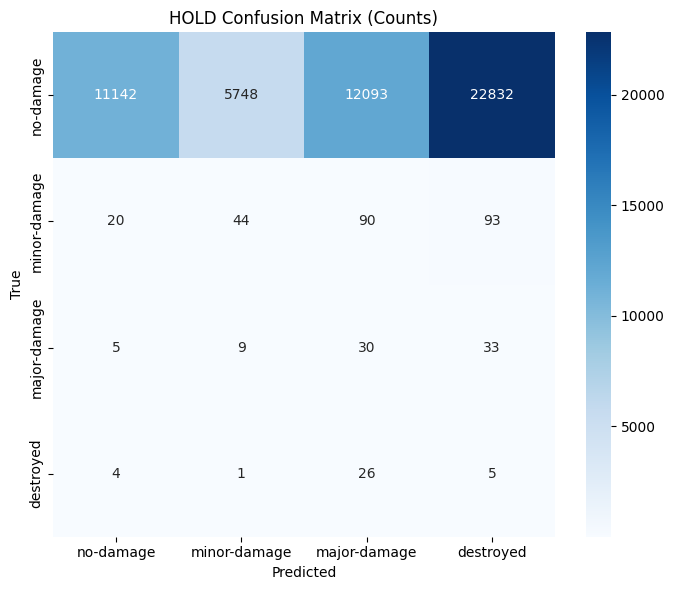

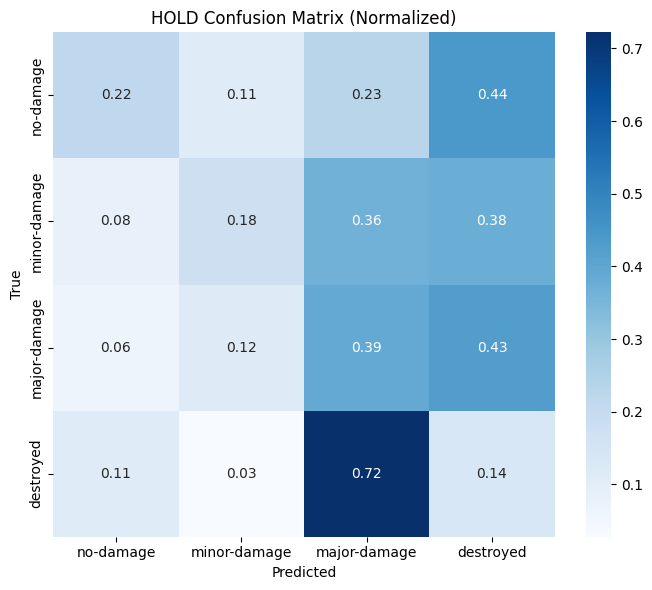

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

# =========================
# Configuration
# =========================

split = "hold"   

labels = ["no-damage", "minor-damage", "major-damage", "destroyed"]

PROJECT_ROOT = Path.cwd()

candidate_paths = [
    PROJECT_ROOT / "OOD_training_outputs" / "beta_tcvae_classifier",
    Path.home() / "Desktop" / "OOD_training_outputs" / "beta_tcvae_classifier",
]

BASE_PATH = None
y_true_path = None
y_pred_path = None

# =========================
# Search logic (robust)
# =========================

for path in candidate_paths:
    
    # Try standard naming
    standard_true = path / f"beta_tcvae_{split}_targets.npy"
    standard_pred = path / f"beta_tcvae_{split}_preds.npy"
    
    # Try OOD naming
    ood_true = path / f"OOD_beta_tcvae__{split}_targets.npy"
    ood_pred = path / f"OOD_beta_tcvae__{split}_preds.npy"
    
    if standard_true.exists() and standard_pred.exists():
        BASE_PATH = path
        y_true_path = standard_true
        y_pred_path = standard_pred
        print("Using standard split naming")
        break
        
    elif ood_true.exists() and ood_pred.exists():
        BASE_PATH = path
        y_true_path = ood_true
        y_pred_path = ood_pred
        print("Using OOD split naming")
        break

# =========================
# Fail clearly if not found
# =========================

if BASE_PATH is None:
    print("Files not found. Available .npy files:\n")
    for path in candidate_paths:
        if path.exists():
            print(f"\n{path}:")
            for f in path.glob("*.npy"):
                print("  ", f.name)
    
    raise FileNotFoundError("Could not find matching prediction files.")

print(f"\nUsing files:\n{y_true_path}\n{y_pred_path}")

# =========================
# Load predictions
# =========================

y_true = np.load(y_true_path)
y_pred = np.load(y_pred_path)

# =========================
# Confusion matrices
# =========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"{split.upper()} Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"{split.upper()} Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()